In [1]:
import csv
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import os

In [2]:
import json
import random
from tqdm import tqdm
import seaborn as sns

# Keywords Analysis

## Create IDs from the current data

In [5]:
ds_test = pd.read_csv("./data_splits_stratified/6-2-2_all_classes_enriched/test.csv")
ds_train = pd.read_csv("./data_splits_stratified/6-2-2_all_classes_enriched/train.csv")
ds_val = pd.read_csv("./data_splits_stratified/6-2-2_all_classes_enriched/val.csv")

In [6]:
# Concatenate (append) the DataFrames vertically
appended_df = pd.concat([ds_test, ds_train, ds_val], ignore_index=True)

In [7]:
appended_df.head()


,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label
0,1,12047012,Schizophrenia bulletin,Can clinical practice guide a research agenda?,Articles from this issue of the Bulletin indic...,Non-systematic-review,1,0
1,2,28832188,Future medicinal chemistry,Dual/multitargeted xanthone derivatives for Al...,"To date, the current therapy for Alzheimer's d...",Non-systematic-review,1,0
2,3,17678496,Expert review of neurotherapeutics,Benefits of occupational therapy in stroke reh...,Stroke is the largest single cause of severe p...,Non-systematic-review,1,0
3,4,25649308,Annals of the New York Academy of Sciences,The promise of ketamine for treatment-resistan...,Major depressive disorder (MDD) is one of the ...,Non-systematic-review,1,0
4,5,6312596,La semaine des hopitaux : organe fonde par l'A...,[Clinical and pathogenic aspects of secondary ...,The secondary hyperlipoproteinemias are freque...,Non-systematic-review,1,0


In [8]:
df_to_fetch_from_doi = pd.read_csv("rayyan_to_pmid_258.csv")
df_to_fetch_from_doi['pmid_from_doi'] = df_to_fetch_from_doi['pmid_from_doi'].astype(str)

In [14]:
merged_df = pd.merge(appended_df, df_to_fetch_from_doi[['pmid', 'pmid_from_doi']], how='left', on='pmid')
merged_df['old_pmid'] = merged_df['pmid']
merged_df.head()

,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label,pmid_from_doi,old_pmid
0,1,12047012,Schizophrenia bulletin,Can clinical practice guide a research agenda?,Articles from this issue of the Bulletin indic...,Non-systematic-review,1,0,NaN,12047012
1,2,28832188,Future medicinal chemistry,Dual/multitargeted xanthone derivatives for Al...,"To date, the current therapy for Alzheimer's d...",Non-systematic-review,1,0,NaN,28832188
2,3,17678496,Expert review of neurotherapeutics,Benefits of occupational therapy in stroke reh...,Stroke is the largest single cause of severe p...,Non-systematic-review,1,0,NaN,17678496
3,4,25649308,Annals of the New York Academy of Sciences,The promise of ketamine for treatment-resistan...,Major depressive disorder (MDD) is one of the ...,Non-systematic-review,1,0,NaN,25649308
4,5,6312596,La semaine des hopitaux : organe fonde par l'A...,[Clinical and pathogenic aspects of secondary ...,The secondary hyperlipoproteinemias are freque...,Non-systematic-review,1,0,NaN,6312596


In [17]:
# Your map of rayyan PMIDs to replace
rayyan_pmid_map = {
    'rayyan-1277751880': 10875051,
    'rayyan-1277750218': 50014,
    'rayyan-1277751843': 11142548,
    'rayyan-1270409883': 6380400,
    'rayyan-1270413930': 22493342,
    'rayyan-1270414149': 23413122
}

# Custom function to replace 'pmid' values based on conditions and the rayyan_pmid_map
def replace_pmid(row):
    if 'rayyan' in row['pmid'] and not pd.isnull(row['pmid_from_doi']):
        return row['pmid_from_doi']
    elif 'rayyan' in row['pmid']:
        return rayyan_pmid_map.get(row['pmid'], row['pmid'])
    else:
        return row['pmid']

# Apply the custom function to create a new 'pmid' column
merged_df['pmid'] = merged_df.apply(replace_pmid, axis=1)
merged_df.drop(columns=['pmid_from_doi'], inplace=True)

merged_df.head()

,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label,old_pmid
0,1,12047012,Schizophrenia bulletin,Can clinical practice guide a research agenda?,Articles from this issue of the Bulletin indic...,Non-systematic-review,1,0,12047012
1,2,28832188,Future medicinal chemistry,Dual/multitargeted xanthone derivatives for Al...,"To date, the current therapy for Alzheimer's d...",Non-systematic-review,1,0,28832188
2,3,17678496,Expert review of neurotherapeutics,Benefits of occupational therapy in stroke reh...,Stroke is the largest single cause of severe p...,Non-systematic-review,1,0,17678496
3,4,25649308,Annals of the New York Academy of Sciences,The promise of ketamine for treatment-resistan...,Major depressive disorder (MDD) is one of the ...,Non-systematic-review,1,0,25649308
4,5,6312596,La semaine des hopitaux : organe fonde par l'A...,[Clinical and pathogenic aspects of secondary ...,The secondary hyperlipoproteinemias are freque...,Non-systematic-review,1,0,6312596


In [19]:
merged_df[merged_df['pmid'].isna() | merged_df['pmid'].str.contains('rayyan', case=False)]


,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label,old_pmid


In [21]:
# Keep only the 'pmid' column
pmid_column = merged_df['pmid']
pmid_column

0       12047012
1       28832188
2       17678496
3       25649308
4        6312596
          ...   
2640    27511183
2641    11520467
2642    36472596
2643    36632763
2644    23703687
Name: pmid, Length: 2645, dtype: object

## Read data with keywords

In [24]:
file_path = "./pubmed/enriched_data_keywords.txt"
#file_path = "test_contents.txt"

# Initialize an empty list to store the data
data = []

# Read the file line by line and split each line by '^'
with open(file_path, 'r') as file:
    for line in file:
        fields = line.strip().split('^')
        if len(fields) > 2:
            # Replace \t separators with |
            fields[-1] = fields[-1].replace('\t', '| ')
        elif len(fields) == 2:
            # If keywords are not available, add "keywords not available" as the third field
            fields.append("")
        data.append(fields)

# Convert the list of lists into a DataFrame
df = pd.DataFrame(data)
df.columns = ['pmid', 'Journal/Title', 'keywords']

In [26]:
df

,pmid,Journal/Title,keywords
0,26201,Acta virologica,
1,50014,The American journal of occupational therapy :...,
2,55891,"Lancet (London, England)",
3,117492,Psychopharmacology,
4,125578,The Australian and New Zealand journal of psyc...,
...,...,...,...
2640,38343329,Journal of applied research in intellectual di...,Arab population| autism| challenging behaviour...
2641,38378836,Translational psychiatry,
2642,38393915,Journal of Alzheimer's disease : JAD,Alzheimer’s disease| PS19 mice| blood-brain ba...
2643,38538761,Scientific reports,


In [28]:
df['keywords'].value_counts()#.get('keywords not available', 0)

keywords
                                                                                                                                                           1778
coronary heart disease| ischaemic heart disease| myocardial infarction                                                                                        1
longitudinal| loss| psychological symptoms| refugees| trust| women-at-risk                                                                                    1
Children and adolescents| Functional Ensemble of Temperament model| In vitro fertilisation| Mood disorders| Schizophrenic disorders                           1
Addiction treatment services| COVID-19| Lockdown| Opioid use disorder                                                                                         1
                                                                                                                                                           ... 
Classification| Functional magn

In [30]:
1778/len(merged_df)

0.6722117202268431

In [32]:
merged_df.head()

,idx,pmid,journal_name,title,abstract,accepted_label,multi_label,binary_label,old_pmid
0,1,12047012,Schizophrenia bulletin,Can clinical practice guide a research agenda?,Articles from this issue of the Bulletin indic...,Non-systematic-review,1,0,12047012
1,2,28832188,Future medicinal chemistry,Dual/multitargeted xanthone derivatives for Al...,"To date, the current therapy for Alzheimer's d...",Non-systematic-review,1,0,28832188
2,3,17678496,Expert review of neurotherapeutics,Benefits of occupational therapy in stroke reh...,Stroke is the largest single cause of severe p...,Non-systematic-review,1,0,17678496
3,4,25649308,Annals of the New York Academy of Sciences,The promise of ketamine for treatment-resistan...,Major depressive disorder (MDD) is one of the ...,Non-systematic-review,1,0,25649308
4,5,6312596,La semaine des hopitaux : organe fonde par l'A...,[Clinical and pathogenic aspects of secondary ...,The secondary hyperlipoproteinemias are freque...,Non-systematic-review,1,0,6312596


In [34]:
enriched_ds_with_kw = merged_df.merge(df, on='pmid', how='left')

# Get the current index of 'journal_name'
journal_name_idx = enriched_ds_with_kw.columns.get_loc('journal_name')
enriched_ds_with_kw.drop(columns=['journal_name'], inplace=True)

# Rename 'Journal/Title' column to 'journal_name'
enriched_ds_with_kw.rename(columns={'Journal/Title': 'journal_name'}, inplace=True)

# Move 'keywords' column before 'accepted_label'
cols = list(enriched_ds_with_kw.columns)
keywords_idx = cols.index('keywords')
accepted_label_idx = cols.index('accepted_label')
cols.insert(accepted_label_idx, cols.pop(keywords_idx))
enriched_ds_with_kw = enriched_ds_with_kw[cols]

# Reorder columns to ensure 'Journal/Title' is in the same order as 'journal_name'
cols = list(enriched_ds_with_kw.columns)
cols.insert(journal_name_idx, cols.pop(-1))
enriched_ds_with_kw = enriched_ds_with_kw[cols]
enriched_ds_with_kw.head()

,idx,pmid,journal_name,title,abstract,keywords,accepted_label,multi_label,binary_label,old_pmid
0,1,12047012,Schizophrenia bulletin,Can clinical practice guide a research agenda?,Articles from this issue of the Bulletin indic...,,Non-systematic-review,1,0,12047012
1,2,28832188,Future medicinal chemistry,Dual/multitargeted xanthone derivatives for Al...,"To date, the current therapy for Alzheimer's d...",Alzheimer's disease| Aβ aggregation| anticholi...,Non-systematic-review,1,0,28832188
2,3,17678496,Expert review of neurotherapeutics,Benefits of occupational therapy in stroke reh...,Stroke is the largest single cause of severe p...,,Non-systematic-review,1,0,17678496
3,4,25649308,Annals of the New York Academy of Sciences,The promise of ketamine for treatment-resistan...,Major depressive disorder (MDD) is one of the ...,antidepressant| bipolar disorder| ketamine| ma...,Non-systematic-review,1,0,25649308
4,5,6312596,La semaine des hopitaux : organe fonde par l'A...,[Clinical and pathogenic aspects of secondary ...,The secondary hyperlipoproteinemias are freque...,,Non-systematic-review,1,0,6312596


In [36]:
enriched_ds_with_kw.shape

(2645, 10)

#### missing data and keywords

In [39]:
# Count missing values for each column individually
missing_counts_per_column = enriched_ds_with_kw[['journal_name', 'title', 'abstract']].isnull().sum()

# Display missing counts
print(missing_counts_per_column)

journal_name    6
title           0
abstract        0
dtype: int64


In [41]:
enriched_ds_with_kw["keywords_empty"] = enriched_ds_with_kw["keywords"].apply(lambda x: 1 if x == "" else 0)
empty_keywords_percentage = enriched_ds_with_kw.groupby("accepted_label")["keywords_empty"].mean() * 100


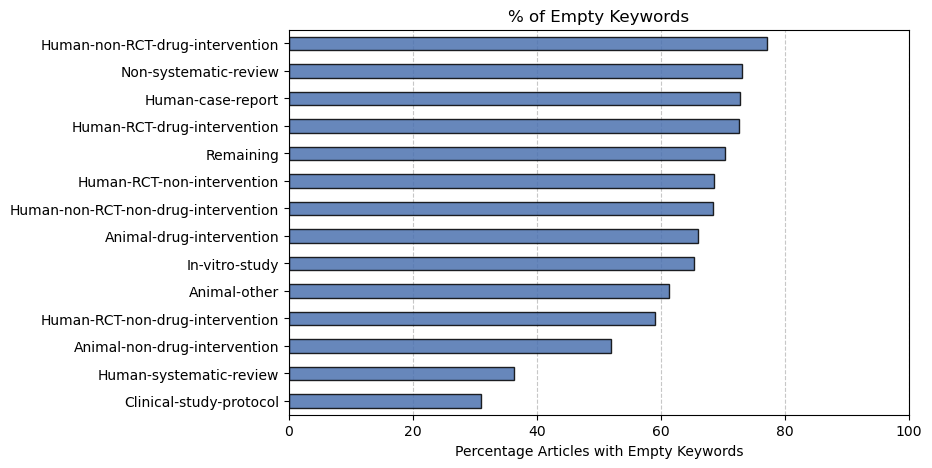

In [43]:
plt.figure(figsize=(8, 5))
empty_keywords_percentage.sort_values().plot(kind="barh", color='#4c72b0', edgecolor='black', alpha=0.85, zorder=2)
plt.title("% of Empty Keywords")
plt.xlabel("Percentage Articles with Empty Keywords")
plt.ylabel("")
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.7, zorder=0)

plt.savefig("viz/empty_keywords_per_label.pdf", bbox_inches='tight')
# Show plot
plt.show()

In [45]:
# Select rows from enriched_ds_with_kw based on PMIDs in ds_test
merged_test = enriched_ds_with_kw[enriched_ds_with_kw['old_pmid'].isin(ds_test['pmid'])]
merged_test.drop(columns=['old_pmid'], inplace=True)

# Select rows from enriched_ds_with_kw based on PMIDs in ds_train
merged_train = enriched_ds_with_kw[enriched_ds_with_kw['old_pmid'].isin(ds_train['pmid'])]
merged_train.drop(columns=['old_pmid'], inplace=True)

# Select rows from enriched_ds_with_kw based on PMIDs in ds_val
merged_val = enriched_ds_with_kw[enriched_ds_with_kw['old_pmid'].isin(ds_val['pmid'])]
merged_val.drop(columns=['old_pmid'], inplace=True)


/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_95559/2750713336.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_test.drop(columns=['old_pmid'], inplace=True)
/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_95559/2750713336.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_train.drop(columns=['old_pmid'], inplace=True)
/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_95559/2750713336.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [47]:
merged_test.to_csv("./data_splits_stratified/6-2-2_all_classes_enriched_with_kw/test.csv", index=False)
merged_train.to_csv("./data_splits_stratified/6-2-2_all_classes_enriched_with_kw/train.csv", index=False)
merged_val.to_csv("./data_splits_stratified/6-2-2_all_classes_enriched_with_kw/val.csv", index=False)

In [49]:
merged_test['accepted_label'].value_counts()

accepted_label
Remaining                              172
Non-systematic-review                   75
Human-non-RCT-non-drug-intervention     42
Human-non-RCT-drug-intervention         36
Human-case-report                       33
Animal-other                            31
Animal-drug-intervention                30
Human-systematic-review                 22
In-vitro-study                          21
Human-RCT-non-drug-intervention         18
Animal-non-drug-intervention            16
Human-RCT-drug-intervention             15
Clinical-study-protocol                 12
Human-RCT-non-intervention              11
Name: count, dtype: int64